# Solution: Drinking Water Demand Forecasting with Recurrent Neural Networks - Part 1
## One-step ahead prediction with Recurrent Neural Networks

This series of Jupyter Notebook exercises focuses on implementing Recurrent Neural Networks (RNN) in `PyTorch`. Throughout this series, you will gain a better understanding of RNNs, a class of neural networks particularly adept at processing sequential data. We will learn by approaching a time series forecasting in the water domain. Of course, the skills and knowledge you acquire here are not limited to this area.

Please go through the Problem Definition and Walkthrough sections of this notebooks, until you reach the Assignments.

## Problem Definition

Water Distribution Systems (WDS) are networked infrastructures designed to provide drinking water to citizens and businesses. Like other critical infrastructure, modern WDS rely on digitalisation to optimize their operations in order to maximise efficiency by ensuring sustainable water management practices.

Digitalisation allows gathering and analysing sensor data to inform control strategies. For instance, accurate forecasting of _drinking water demands_ over shor-time horizons (e.g., 24 hours) can be used to better manage the operations of the pumping stations of the WDS, as well as optimizing the production of drinking water from water treatment plants.

Water demand time series are usually recorded by flow meters located at the inlet of a district. This data can then be used to develop forecasting methods, which are usually based on time series analysis techniques or, more recently, machine learning (ML). Typical input data for these models are past water demands, meteorological data, and calendar information (e.g., day of the week, holidays, important events, ...).


<br/>


<center><figure>
  <img src="https://ars.els-cdn.com/content/image/1-s2.0-S0377042716300565-gr6_lrg.jpg" width=600/>
<figcaption>Figure 1. Water demand forecasting: observed data vs machine learning prediction.
    
<sub><sup>Image credits: Brentan et al. (2017), https://doi.org/10.1016/j.wroa.2019.100028 </sup></sub></figcaption>
</figure></center>

The data for this assignment was kindly provided by the authors of [1]. The data refers to hourly measurments from a real WDS serving around 120k users (residential and industrial) of a medium-sized city of Northern Italy. The data spans two years and includes hourly average water demand in [L/s] (liters per second). You will be using the data to _train_ and _validate_ different Deep Learning (DL) models based on Feed Forward Neural Networks and Recurrent Neural Networks.

In this first notebook, the goal is to compare different architectures for the **one-step ahead forecasting of water demand**.

<u> References </u>

[1] Pacchin, E., Gagliardi, F., Alvisi, S. and Franchini, M., 2019. A comparison of short-term water demand forecasting models. Water resources management, 33(4), pp.1481-1497.


## Load python modules

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import time
import os
from urllib.request import urlretrieve

from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

In [2]:
# Check if CUDA is available, otherwise use CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


# Download and load the data

In [ ]:
# Download the water demand dataset
year_1 = "https://surfdrive.surf.nl/files/index.php/s/T2SN8dnXXYWz4q5/download"
year_2 = "https://surfdrive.surf.nl/files/index.php/s/StRwCboQoDPRGdD/download"

data_folder = "data"
water_demand_file1 = os.path.join(data_folder, "water_demand_Y1.txt")
water_demand_file2 = os.path.join(data_folder, "water_demand_Y2.txt")

if not os.path.isfile(water_demand_file1):
    print("Downloading dataset...")
    os.makedirs("data", exist_ok=True)
    urlretrieve(year_1, water_demand_file1)
    urlretrieve(year_2, water_demand_file2)

## Exploratory data analysis

We are loading data from the two years and concatenating them for joint analysis.

> Note: You can choose to work with only one of the two years to expedite training.


In [4]:
# load water demand data
df_year1 = pd.read_csv(water_demand_file1,header=None, sep=r"\s+")
df_year2 = pd.read_csv(water_demand_file2,header=None, sep=r"\s+")
df = pd.concat([df_year1, df_year2], axis = 0).reset_index(drop=True)
df.head()

,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
0,699.9350,740.6850,714.9900,684.2525,597.7575,519.2425,510.1450,614.8825,795.5500,1006.1300,...,1026.0875,918.0225,906.0375,902.1875,922.1850,950.3275,966.3725,877.0875,791.2575,744.4600
1,650.4700,593.2275,539.6425,520.6075,511.2000,500.0075,617.5375,837.5200,987.4875,1081.5075,...,981.8050,908.3025,895.2125,894.2750,976.5050,1016.4225,1057.3275,961.8975,823.3100,775.7425
2,689.5650,610.3225,578.1475,541.6100,521.8300,514.6875,624.4775,838.6775,1012.2075,1105.9875,...,1023.3050,917.2225,905.3750,943.5700,984.5625,1051.1925,1063.4275,953.9950,823.5075,754.7550
3,713.5525,620.6775,569.6550,551.5575,526.7850,518.5625,563.0475,748.1525,965.0550,1149.5875,...,1065.4375,996.6850,988.6625,989.1775,1034.6575,1056.6000,1006.7700,902.1275,804.0650,788.1050
4,723.4175,633.9325,575.2450,545.4650,526.8325,498.9925,523.3400,645.5475,881.3875,1129.3075,...,1070.7375,970.1500,942.8125,933.8925,963.5175,983.4775,988.2550,875.5950,793.1400,761.0325


Let's visualize the typical pattern of a random day in our data. In general, these patterns show two peaks of consumption: in the morning and in the evening. Consumption is at its lowest during late night and early mornings.

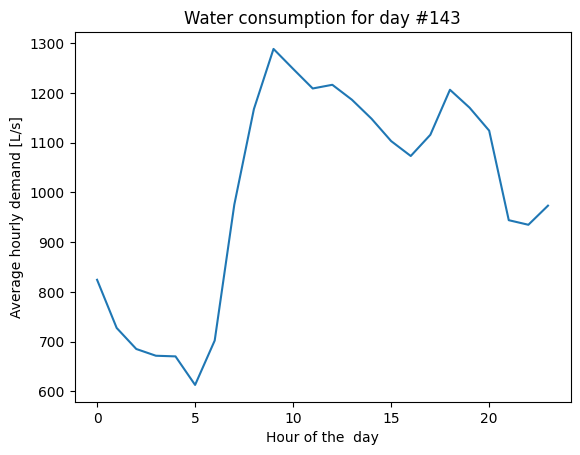

In [5]:
# plot random day
day_ix = np.random.randint(len(df))
ax = df.loc[day_ix].plot()
ax.set_xlabel('Hour of the  day');
ax.set_ylabel('Average hourly demand [L/s]');
ax.set_title(f'Water consumption for day #{day_ix}');

We can obtain more information on the hour-by-hour distribution of the water demand by using boxplots. These are computed across all days for each hour of the day. By plotting the distribution for both years we see that <u> consumptions increased in Year #2 </u>. This also emerges from the overall average (red line).

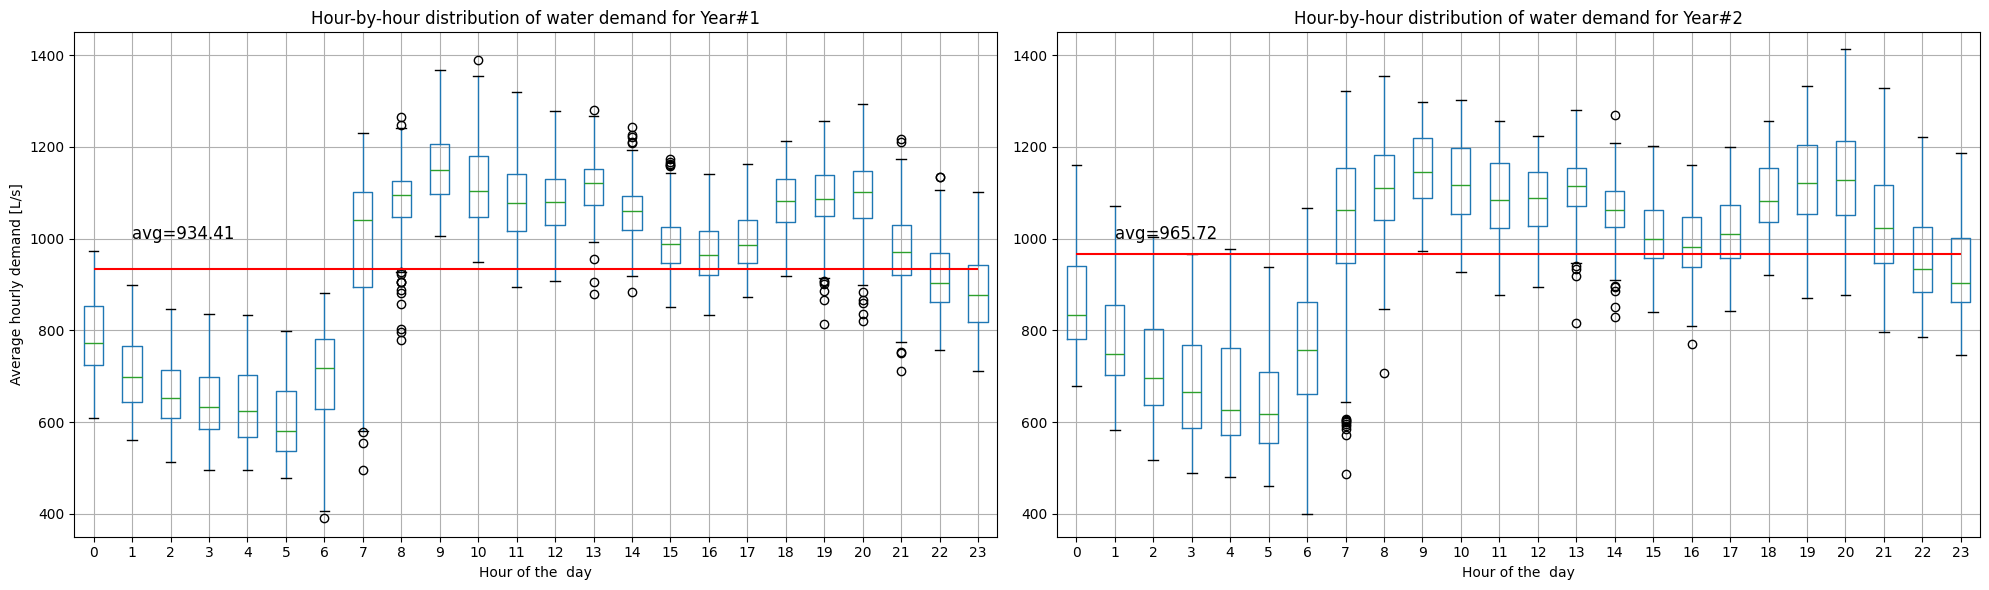

In [6]:
# plot hourly water demand distributions across all days

# year 1
f, axes = plt.subplots(1,2,figsize=(20,6))
df_year1.boxplot(ax=axes[0])
axes[0].set_xlabel('Hour of the  day');
axes[0].set_ylabel('Average hourly demand [L/s]');
axes[0].set_title('Hour-by-hour distribution of water demand for Year#1');
axes[0].set_ylim([350,1450])

avg_year1 = df_year1.values.reshape(-1).mean()
axes[0].hlines(avg_year1,1,24, colors='r')
axes[0].text(2, 1000, f'avg={avg_year1:.2f}', fontsize=12)

# year 2
df_year2.boxplot(ax=axes[1])
axes[1].set_xlabel('Hour of the  day');
# axes[1].set_ylabel('Average hourly demand [L/s]');
axes[1].set_title('Hour-by-hour distribution of water demand for Year#2');
axes[1].set_ylim([350,1450])

avg_year2 = df_year2.values.reshape(-1).mean()
axes[1].hlines(avg_year2,1,24, colors='r')
axes[1].text(2, 1000, f'avg={avg_year2:.2f}', fontsize=12)

f.tight_layout()

## Creation of dataset and data normalization/standardization

The following code snippets serve two essential functions:

1. `create_sequences`:
   - This function creates input/output sequences from a given time series.
   - The input sequence spans T time steps, from time t to time t+T (excluded).
   - The output sequence spans H time steps, from time t+T to time t+T+H (excluded).
   - In the current notebook, we use H = 1 for predicting one step ahead. And T = 168, that is all hourly data up to 1 week before.

2. `scale_sequences`:
   - This function scales or normalizes sequences.
   - If a scaler is provided, it transforms the sequences using that scaler.
   - If no scaler is provided, it creates a scaler based on the specified `scaler_type` ('standard' or 'minmax') and then transforms the sequences.
   - The scaled sequences are returned along with the scaler used (or `None` if a scaler was provided).


In [7]:
def create_sequences(series,T=168,H=24):
    # This function creates a dataset of input/output sequences from a time series.
    # The input sequence is T steps long, from time t to time t+T (excluded).
    # The output sequence is H steps long, from time t+T to time t+T+H (excluded).
    X = []
    Y = []
    for t in range(len(series)-T-H):
        x = series[t:t+T]
        X.append(x)
        y = series[t+T:t+T+H]
        Y.append(y)
    X = np.array(X)
    Y = np.array(Y)
    return X,Y

def scale_sequences(X,scaler=None,scaler_type='standard'):
    # Uses a standard scaler to transform sequences. The scaler is created if no scaler is passed as argument.
    Xshape=X.shape
    if scaler:
        X = scaler.transform(X.reshape(-1,1)).reshape(Xshape)
        return X
    else:
        if scaler_type == 'standard':
            scaler = StandardScaler()
        elif scaler_type == 'minmax':
            scaler = MinMaxScaler()
        else:
            raise Exception("Type of scikit-learn scaler not supported. Choose 'standard' or 'minmax.")
        X = scaler.fit_transform(X.reshape(-1,1)).reshape(Xshape)
        return X, scaler

We now create the sequence datasets for _training_, _validating_ and _testing_ our DL methods.

In [8]:
T = 168     # number of time steps to use for prediction (168 hours = 1 week)
H = 1       # number of time steps to predict (1 hour)
X, Y = create_sequences(df.values.reshape(-1),T=T,H=H)
print(X.shape)
print(Y.shape)

(17351, 168)
(17351, 1)


As you can see, each input-ouput pair is made of: 1) an input sequence of 168 hours (e.g., 1 week) and 2) an output sequence of 1 hours.

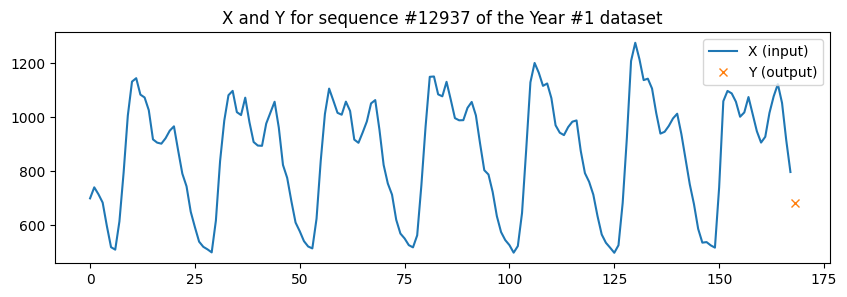

In [9]:
random_ix = np.random.choice(X.shape[0])
f, ax = plt.subplots(1,figsize=(10,3))
ax.plot(np.arange(T),X[0], label='X (input)')
ax.plot(np.arange(T,T+H),Y[0], 'x', label = 'Y (output)')
ax.set_title(f'X and Y for sequence #{random_ix} of the Year #1 dataset');
ax.legend();

These sequences are not normalized yet, and we need to split them into training and validation. We first perform the latter task and then we use ```scale_sequences``` to perform the scaling. Is important to use the scaler "fitted" for the training dataset to scale tha validation dataset and then the test dataset). Since the input and output variables are both water demand, we only need to fit one scaler. ```scale_sequences``` recognize whether to fit a scaler or use an existing one based on the arguments it receives when called.

In [10]:
# We keep track of indexes of train and validation.
X_tra, X_tst, Y_tra, Y_tst, ix_tra, ix_tst = train_test_split(
    X, Y, np.arange(X.shape[0]), test_size=0.30, shuffle=True, random_state=42)

# Split the existing test dataset into validation and test sets (50/50 split)
X_val, X_tst, Y_val, Y_tst, ix_val, ix_tst = train_test_split(
    X_tst, Y_tst, ix_tst, test_size=0.5, shuffle=True, random_state=42)


print(f"X_tra.shape: {X_tra.shape}, Y_tra.shape: {Y_tra.shape}")
print(f"X_val.shape: {X_val.shape}, Y_val.shape: {Y_val.shape}")
print(f"X_tst.shape: {X_tst.shape}, Y_tst.shape: {Y_tst.shape}")

X_tra.shape: (12145, 168), Y_tra.shape: (12145, 1)
X_val.shape: (2603, 168), Y_val.shape: (2603, 1)
X_tst.shape: (2603, 168), Y_tst.shape: (2603, 1)


Let's plot a random sequence from the training dataset

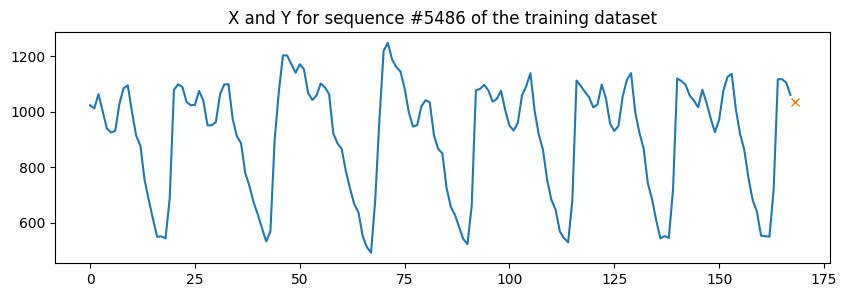

In [11]:
random_ix = np.random.choice(X_tra.shape[0])
f, ax = plt.subplots(1,figsize=(10,3))
ax.plot(np.arange(T),X_tra[random_ix], label='Xtra')
ax.plot(np.arange(T,T+H),Y_tra[random_ix], 'x', label = 'Ytra')
ax.set_title(f'X and Y for sequence #{random_ix} of the training dataset');

Now we scale all data. Remember: <u>you "fit" the scaler using training data </u>; when you develop your machine learning models, you have to assume that you have no information on validation and test data.

In [12]:
# scale/normalize
X_tra, scaler = scale_sequences(X_tra, scaler_type='standard')
Y_tra = scale_sequences(Y_tra, scaler)
X_val = scale_sequences(X_val, scaler)
Y_val = scale_sequences(Y_val, scaler)
X_tst = scale_sequences(X_tst, scaler)
Y_tst = scale_sequences(Y_tst, scaler)

As you can see, the sequences before and after normalization look the same, but the ranges are different.

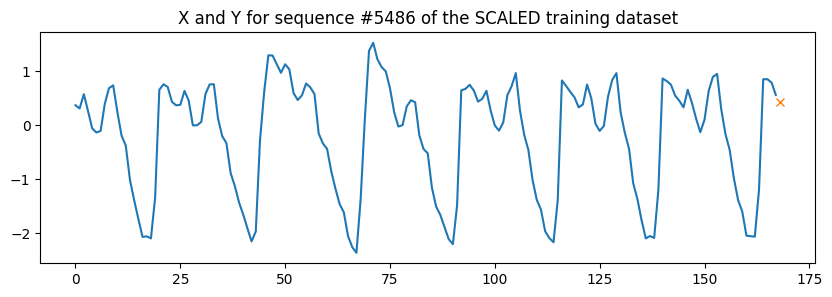

In [13]:
f, ax = plt.subplots(1,figsize=(10,3))
ax.plot(np.arange(T),X_tra[random_ix], label='Xtra')
ax.plot(np.arange(T,T+H),Y_tra[random_ix], 'x', label = 'Y (output)')
ax.set_title(f'X and Y for sequence #{random_ix} of the SCALED training dataset');

## Definition of MultiLayer Perceptron and Simple Recurrent Neural Network

Now, we will compare the performance of a Multilayer Perceptron (MLP) against a Simple Recurrent Neural Network (RNN). This comparison aims to assess whether the RNN's sequential inductive bias provides any advantages in modeling and predicting our time series data.


In [14]:
class MLP(nn.Module):
    def __init__(self, hidden_size, output_size):
        super(MLP, self).__init__()
        # Define the layers of the network
        self.fc1 = nn.Linear(T, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # Define the forward pass
        x = F.tanh(self.fc1(x))  # Activation function (ReLU) after first layer
        x = F.tanh(self.fc2(x))  # Activation function (ReLU) after second layer
        x = self.fc3(x)          # Output layer
        return x

In [15]:
class SimpleRNN(nn.Module):
    def __init__(self, hidden_size, output_size):
        super(SimpleRNN, self).__init__()
        # RNN layer
        self.rnn = nn.RNN(input_size=1, hidden_size=hidden_size, batch_first=True)

        # Output layer
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # Reshape input to have feature dimension of 1
        x = x.unsqueeze(-1)   # Assuming input x has shape (batch, sequence)

        # RNN layer
        x, hn = self.rnn(x)   # We do not need the hidden states hn

        # Select the output of the last time step
        x = x[:, -1, :]

        # Output layer
        x = self.fc(x)

        return x

### Functions for training loop end evaluation

In [16]:
def evaluate_model(model, test_loader, criterion, device):
    model.eval()  # Set the model to evaluation mode
    test_loss = 0

    with torch.no_grad():  # No need to track gradients during evaluation
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            test_loss += loss.item()

    avg_test_loss = test_loss / len(test_loader)
    return avg_test_loss

def train_and_validate(model, train_loader, val_loader, criterion, optimizer, num_epochs, device, save_path, echo_iter = 20):
    best_val_loss = float("inf")  # Track the best validation loss
    train_losses = []
    val_losses = []

    start_time = time.time()  # Start training time

    for epoch in range(num_epochs):
        # Training Phase
        model.train()
        total_train_loss = 0
        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            total_train_loss += loss.item()

        avg_train_loss = total_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # Validation Phase
        avg_val_loss = evaluate_model(model, val_loader, criterion, device)
        val_losses.append(avg_val_loss)

        # Save Best Model
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), save_path)

        if echo_iter > 0:
            if (epoch + 1) % echo_iter == 0:
                print(f'Epoch {epoch+1}/{num_epochs}', f'Train Loss: {avg_train_loss:.4f}, '
                      f'Validation Loss: {avg_val_loss:.4f}', f'Best Validation Loss: {best_val_loss:.4f}')
                
    train_time = time.time() - start_time
    if echo_iter > 0:
        print("Training complete.")
    return train_losses, val_losses, best_val_loss, train_time

### MLP vs SimpleRNN comparison


We create the `TensorDatasets` and the `DataLoaders`. We also set equal training epochs and learning rate for both architectures.

In [17]:
train_dataset = TensorDataset(torch.tensor(X_tra, dtype=torch.float32), torch.tensor(Y_tra, dtype=torch.float32))
val_dataset = TensorDataset(torch.tensor(X_val, dtype=torch.float32), torch.tensor(Y_val, dtype=torch.float32))
test_dataset = TensorDataset(torch.tensor(X_tst, dtype=torch.float32), torch.tensor(Y_tst, dtype=torch.float32 ))

In [18]:
batch_size = 256      # You can modify this based on your requirements

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [19]:
num_epochs = 200
lr = 0.0005

#### Training MLP

In [20]:
model_MLP = MLP(256, H).to(device)

In [21]:
# Loss function
criterion = nn.MSELoss()  # Or another appropriate loss function

optimizer = optim.AdamW(model_MLP.parameters(), lr=lr)
save_path_MLP = './models/MLP_model.pth'

if not os.path.exists('./models'):
    os.makedirs('./models')

In [22]:
train_losses_MLP, val_losses_MLP, best_val_loss_MLP, time_MLP = train_and_validate(model_MLP, train_loader, val_loader, criterion, optimizer, num_epochs, device, save_path_MLP)

Epoch 20/200 Train Loss: 0.0213, Validation Loss: 0.0273 Best Validation Loss: 0.0243
Epoch 40/200 Train Loss: 0.0183, Validation Loss: 0.0231 Best Validation Loss: 0.0220
Epoch 60/200 Train Loss: 0.0162, Validation Loss: 0.0230 Best Validation Loss: 0.0213
Epoch 80/200 Train Loss: 0.0160, Validation Loss: 0.0221 Best Validation Loss: 0.0205
Epoch 100/200 Train Loss: 0.0145, Validation Loss: 0.0209 Best Validation Loss: 0.0205
Epoch 120/200 Train Loss: 0.0133, Validation Loss: 0.0211 Best Validation Loss: 0.0202
Epoch 140/200 Train Loss: 0.0133, Validation Loss: 0.0215 Best Validation Loss: 0.0195
Epoch 160/200 Train Loss: 0.0120, Validation Loss: 0.0197 Best Validation Loss: 0.0194
Epoch 180/200 Train Loss: 0.0111, Validation Loss: 0.0194 Best Validation Loss: 0.0191
Epoch 200/200 Train Loss: 0.0104, Validation Loss: 0.0202 Best Validation Loss: 0.0191
Training complete.


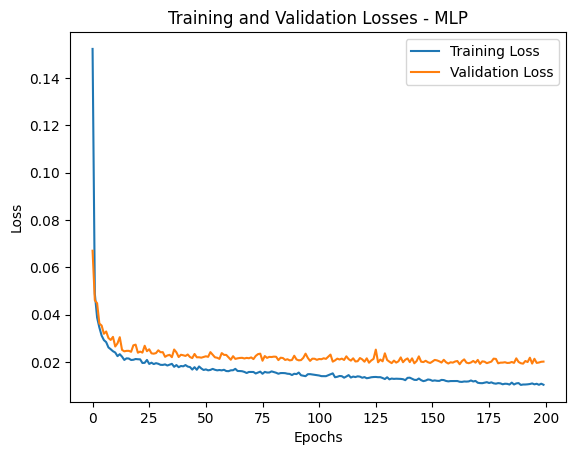

In [23]:
plt.plot(train_losses_MLP, label='Training Loss')
plt.plot(val_losses_MLP, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Losses - MLP')
plt.legend()
plt.show()

In [24]:
# Load the best model
model_MLP.load_state_dict(torch.load(save_path_MLP))

<All keys matched successfully>

#### Training SimpleRNN

In [25]:
model_RNN = SimpleRNN(128, H).to(device)

In [26]:
# Loss function
criterion = nn.MSELoss()  # Or another appropriate loss function

optimizer = optim.AdamW(model_RNN.parameters(), lr=lr)
save_path_RNN = './models/RNN_model.pth'

In [27]:
train_losses_RNN, val_losses_RNN, best_val_loss_RNN, time_RNN = train_and_validate(model_RNN, train_loader, val_loader, criterion, optimizer, num_epochs, device, save_path_RNN)

Epoch 20/200 Train Loss: 0.0516, Validation Loss: 0.0603 Best Validation Loss: 0.0532
Epoch 40/200 Train Loss: 0.1462, Validation Loss: 0.1419 Best Validation Loss: 0.0379
Epoch 60/200 Train Loss: 0.0897, Validation Loss: 0.0863 Best Validation Loss: 0.0379
Epoch 80/200 Train Loss: 0.1000, Validation Loss: 0.0917 Best Validation Loss: 0.0379
Epoch 100/200 Train Loss: 0.0580, Validation Loss: 0.0563 Best Validation Loss: 0.0379
Epoch 120/200 Train Loss: 0.0468, Validation Loss: 0.0460 Best Validation Loss: 0.0379
Epoch 140/200 Train Loss: 0.0876, Validation Loss: 0.0837 Best Validation Loss: 0.0379
Epoch 160/200 Train Loss: 0.0650, Validation Loss: 0.0642 Best Validation Loss: 0.0379
Epoch 180/200 Train Loss: 0.0643, Validation Loss: 0.0621 Best Validation Loss: 0.0379
Epoch 200/200 Train Loss: 0.0499, Validation Loss: 0.0507 Best Validation Loss: 0.0379
Training complete.


In [28]:
# Load the best model
model_RNN.load_state_dict(torch.load(save_path_RNN))

<All keys matched successfully>

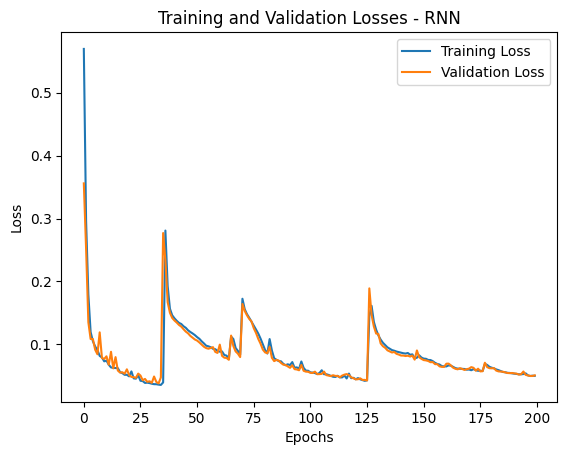

In [29]:
plt.plot(train_losses_RNN, label='Training Loss')
plt.plot(val_losses_RNN, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Losses - RNN')
plt.legend()
plt.show()

### Comparison

In [30]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

avg_test_loss_MLP = evaluate_model(model_MLP, test_loader, criterion, device)
avg_test_loss_RNN = evaluate_model(model_RNN, test_loader, criterion, device)

print(f"MLP --> num. trainable parameters:{count_parameters(model_MLP):8d} | Best Val Loss: {best_val_loss_MLP:.4f} | Test loss: {avg_test_loss_MLP:.4f} | Training time: {time_MLP:.2f}")
print(f"RNN --> num. trainable parameters:{count_parameters(model_RNN):8d} | Best Val Loss: {best_val_loss_RNN:.4f} | Test loss: {avg_test_loss_RNN:.4f} | Training time: {time_RNN:.2f}")

MLP --> num. trainable parameters:  109313 | Best Val Loss: 0.0191 | Test loss: 0.0166 | Training time: 15.30
RNN --> num. trainable parameters:   16897 | Best Val Loss: 0.0379 | Test loss: 0.0351 | Training time: 19.61


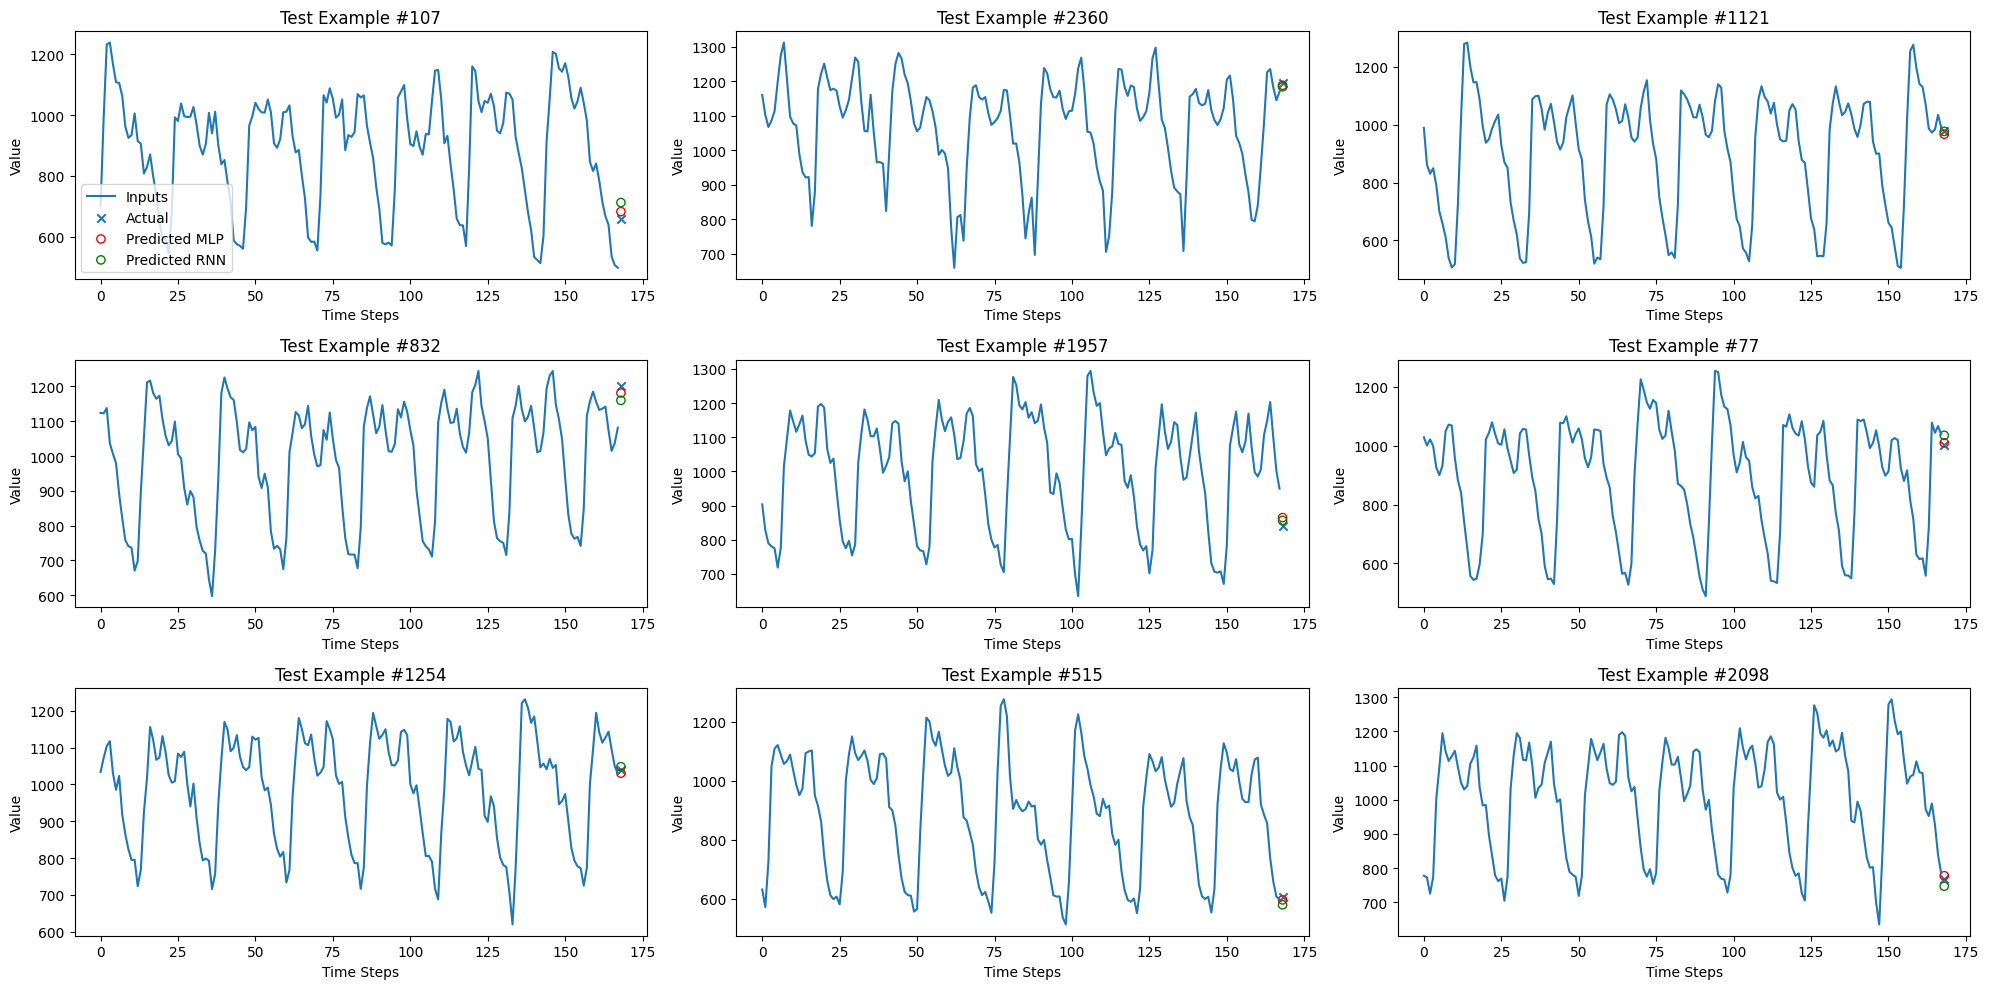

In [31]:
model_MLP.eval()
model_RNN.eval()

f,axes = plt.subplots(3,3, figsize=(20,10))

for ix, ax in enumerate(axes.reshape(-1)):
  with torch.no_grad():
      # Randomly select a sample from the test dataset
      random_index = random.randint(0, len(test_dataset) - 1)
      inputs, target = test_dataset[random_index]
      inputs, target = inputs.to(device).unsqueeze(0), target.to(device).unsqueeze(0)

      # Predict
      prediction_MLP = model_MLP(inputs)
      prediction_RNN = model_RNN(inputs)

      # Rescale inputs, target, and prediction using the scaler
      inputs_rescaled = scaler.inverse_transform(inputs.cpu().numpy().flatten().reshape(-1, 1)).flatten()
      target_rescaled = scaler.inverse_transform(target.cpu().numpy().flatten().reshape(-1, 1)).flatten()
      prediction_MLP_rescaled = scaler.inverse_transform(prediction_MLP.cpu().numpy().flatten().reshape(-1, 1)).flatten()
      prediction_RNN_rescaled = scaler.inverse_transform(prediction_RNN.cpu().numpy().flatten().reshape(-1, 1)).flatten()

      # Plotting inputs (time series)
      ax.plot(np.arange(T), inputs_rescaled, label='Inputs')

      # Plotting prediction vs target
      ax.scatter(np.arange(T, T+H), target_rescaled, marker='x', label='Actual')
      ax.scatter(np.arange(T, T+H), prediction_MLP_rescaled, marker='o', facecolors='none', edgecolors='r', label='Predicted MLP')
      ax.scatter(np.arange(T, T+H), prediction_RNN_rescaled, marker='o', facecolors='none', edgecolors='g', label='Predicted RNN')

      ax.set_title(f'Test Example #{random_index}')
      ax.set_xlabel('Time Steps')
      ax.set_ylabel('Value')
      if ix == 0:
        ax.legend()

f.tight_layout()

## Assignments

1. **Store your best RNN and MLP**
   - We will need your best models for Part 2 of this series of notebooks. Make sure to save somewhere the files where you stored your best RNN and MLP models.
   - If you are using Google Colab, you can store these files after connecting your Google Drive (see previous notebooks). 
   - You can also quickly download them as follows:
 
     `from google.colab import files`
     
     `files.download(<folder of the file>/<file name>)`

2. **Comparison between RNN and MLP**
  - Critically analyze the performance differences between the Recurrent Neural Network (RNN) and the Multi-Layer Perceptron (MLP) models. Determine which model yielded better results and discuss the reasons for this performance difference.

> <u>Answer</u>. The MLP seems to yield better results for this dataset, at least according to the basic implementation. However, this results are achieved with much larger models (e.g., >5 times bigger). That said, tweaking some hyperparameters (e.g., number of epochs, learning rates, size of the RNNs) could yield different results. On the other hand, the poorer performance of the RNN may indicate that accurate one-step ahead forecast of water demand can be achieved by relying on only a few previous elements in the time series, either just before the timestamp to predict, or at the same time of the day but in previous days. Exploiting more complex patterns may not be useful for this task, undermining the usefullness of RNNs. 

3. **Loss Curve Analysis**
  - Review the training and validation loss curves for both the RNN and MLP models. Identify any notable patterns or anomalies in these curves. Describe these observations.

> <u>Answer</u>. The MLP learns fast and displays a relatively smooth training curve. On the other hand, training the RNN is more complicated; the sudden spikes in the training and validation losses indicate training instability, at least for the basic model we trained. 

4. **Tweak hyperparameters**
  - Play around with the complexity (e.g., size) of these networks and other hyperparameters such as the learning rate or number of epochs. Do you see any major changes in performance? If so, why?

> See below

5. **Change the length of the input sequence**
  - Decrease the length of the input sequence to one day and two days. Re-do the experiments for both MLP and RNN. You can work with your fellow classmates to proceed in parallel.
  - What do you see? Are the performance increasing or decreasing, or are they essentially the same? Critically analyze these results.

> See below

### Assignment 4 - Tweak hyperparameters

We'll use this opportunity to showcase **grid search**, a technique for systematically testing multiple hyperparameter combinations to find the best neural network architecture. Grid search thoroughly evaluates each combination of predefined hyperparameters, such as layer sizes and learning rates. This approach can be less viable when lacking sufficient computational resources or having access to timed environments like *Google Colab*.







In [32]:
import itertools

# Consider multiple combinations with a "grid search approach"
ANN_type = ['MLP','SimpleRNN']
hidden_size = [32, 64, 128, 256, 512]
num_epochs = [500] # we train for longer
lr = [0.0001, 0.0005, 0.001]
batch_size = [256]

all_combinations = list(itertools.product(*[ANN_type,hidden_size,num_epochs,lr,batch_size]))

# Create dataframe storing results for different combination of hyperparameters
res_df = pd.DataFrame(index=np.arange(len(all_combinations)),
                          columns=['ann_type','hidden_size','num_epochs','lr','batch_size','model_name',
                                   'tr_loss','val_loss','elapsed_time','trainable_params'])

res_df.head()

,ann_type,hidden_size,num_epochs,lr,batch_size,model_name,tr_loss,val_loss,elapsed_time,trainable_params
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


We employ `tqdm` to enhance the visualization of our process's progress. `tqdm` is a versatile Python library that provides a fast, extensible progress bar for loops and iterations. To ensure seamless integration with `tqdm`, we required a modified `train_and_validate` function that allows suppressing output to the screen, as such output could interfere with the progress bar display. You might have already observed that the `train_and_validate` function in this notebook slightly differs from the one in the original one you have been provided.

In [33]:
from tqdm import tqdm # for better visualization of progress

histories = [] # store training histories for each model

for i, combination in tqdm(enumerate(all_combinations), total=len(all_combinations)):
    # retrieve and store hyperparameters
    ANN_type_, hidden_size_, num_epochs_, lr_, batch_size_ = combination
    res_df.loc[i,['ann_type','hidden_size','num_epochs','lr','batch_size']] = combination

    # create and store model name
    model_name = f"model_{i:03d}"
    res_df.loc[i,['model_name']] = model_name
    
    # create model
    if ANN_type_ == 'MLP':        
        this_model = MLP(hidden_size_, H).to(device)
    elif ANN_type_ == 'SimpleRNN':        
        this_model = SimpleRNN(hidden_size_, H).to(device)
    else:
        raise Exception("Model Not Found!")
        
    res_df.loc[i,'trainable_params'] = count_parameters(this_model)

    criterion = nn.MSELoss()
    optimizer = optim.AdamW(this_model.parameters(), lr=lr_)
    save_path = f'./models/{model_name}.pth'
    train_loader = DataLoader(train_dataset, batch_size=batch_size_, shuffle=True)

    train_losses, val_losses, _, elapsed_time = train_and_validate(this_model, train_loader, val_loader, criterion, optimizer, num_epochs_, device, save_path, echo_iter = 0)

    best_iter = np.array(val_losses).argmin()
    
    res_df.loc[i,['tr_loss','val_loss','elapsed_time']] = train_losses[best_iter], val_losses[best_iter], elapsed_time

    histories.append({'train_losses': train_losses, 'val_losses': val_losses})

100%|██████████| 30/30 [29:05<00:00, 58.18s/it] 


In [34]:
res_df.to_csv('results.csv')

ann_type                  MLP
hidden_size               256
num_epochs                500
lr                     0.0005
batch_size                256
model_name          model_010
tr_loss              0.008045
val_loss             0.018553
elapsed_time        39.827939
trainable_params       109313
Name: 10, dtype: object


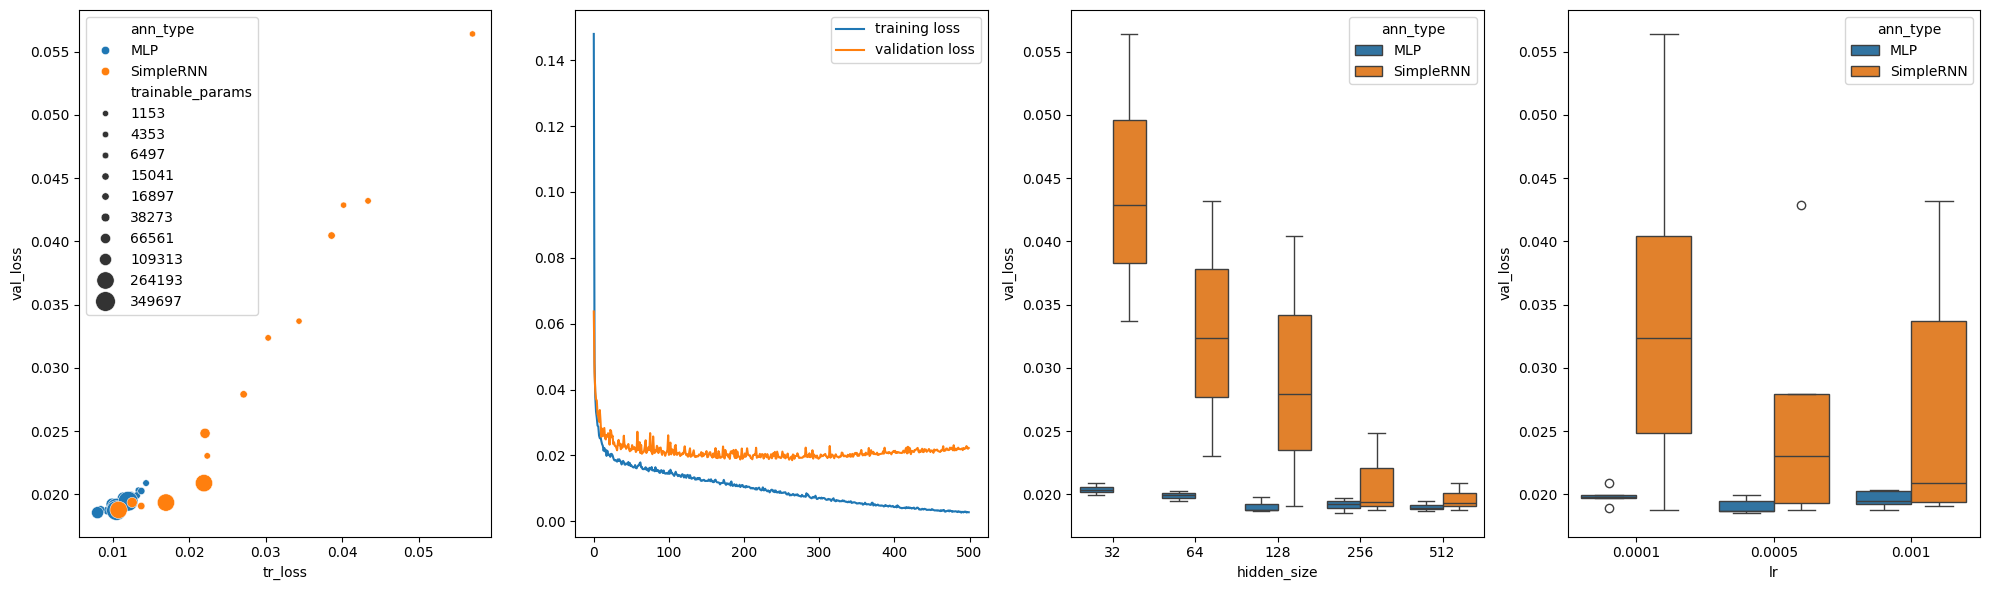

In [35]:
import seaborn as sns

f, axes = plt.subplots(1,4,figsize=(20,6))
sns.scatterplot(
    data=res_df, x="tr_loss", y="val_loss", size="trainable_params", hue="ann_type", sizes=(20, 200), legend="full", ax=axes[0]);

best_model_ix = res_df['val_loss'].astype(float).idxmin()
print(res_df.loc[best_model_ix])
axes[1].plot(histories[best_model_ix]['train_losses'], label='training loss')
axes[1].plot(histories[best_model_ix]['val_losses'], label='validation loss')
axes[1].legend()

sns.boxplot(x='hidden_size',y='val_loss', hue='ann_type', data=res_df, ax = axes[2])
sns.boxplot(x='lr',y='val_loss', hue='ann_type', data=res_df, ax = axes[3])

f.tight_layout()

**Comment on the results**: It looks like with hyper-parameter tweaking, RNNs trained for longer can reach similar performances to that of MLPs. However, RNNs are still more difficult to train, with several models providing subpar performance.

### Assignment 5 - Changing the length of the input sequence

We re-do the experiments with 2 days of sequence length and see what happens.

In [36]:
T = 48     # number of time steps to use for prediction (48 hours = 2 days)
H = 1      # number of time steps to predict (1 day)
X, Y = create_sequences(df.values.reshape(-1),T=T,H=H)
print(X.shape)
print(Y.shape)

(17471, 48)
(17471, 1)


In [37]:
# We keep track of indexes of train and validation.
X_tra, X_tst, Y_tra, Y_tst, ix_tra, ix_tst = train_test_split(
    X, Y, np.arange(X.shape[0]), test_size=0.30, shuffle=True, random_state=42)

# Split the existing test dataset into validation and test sets (50/50 split)
X_val, X_tst, Y_val, Y_tst, ix_val, ix_tst = train_test_split(
    X_tst, Y_tst, ix_tst, test_size=0.5, shuffle=True, random_state=42)


print(f"X_tra.shape: {X_tra.shape}, Y_tra.shape: {Y_tra.shape}")
print(f"X_val.shape: {X_val.shape}, Y_val.shape: {Y_val.shape}")
print(f"X_tst.shape: {X_tst.shape}, Y_tst.shape: {Y_tst.shape}")

X_tra.shape: (12229, 48), Y_tra.shape: (12229, 1)
X_val.shape: (2621, 48), Y_val.shape: (2621, 1)
X_tst.shape: (2621, 48), Y_tst.shape: (2621, 1)


In [38]:
# scale/normalize
X_tra, scaler = scale_sequences(X_tra, scaler_type='standard')
Y_tra = scale_sequences(Y_tra, scaler)
X_val = scale_sequences(X_val, scaler)
Y_val = scale_sequences(Y_val, scaler)
X_tst = scale_sequences(X_tst, scaler)
Y_tst = scale_sequences(Y_tst, scaler)

In [39]:
train_dataset = TensorDataset(torch.tensor(X_tra, dtype=torch.float32), torch.tensor(Y_tra, dtype=torch.float32))
val_dataset = TensorDataset(torch.tensor(X_val, dtype=torch.float32), torch.tensor(Y_val, dtype=torch.float32))
test_dataset = TensorDataset(torch.tensor(X_tst, dtype=torch.float32), torch.tensor(Y_tst, dtype=torch.float32 ))

batch_size = 256      # You can modify this based on your requirements

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [40]:
# Consider multiple combinations with a "grid search approach"
ANN_type = ['MLP','SimpleRNN']
hidden_size = [64, 128, 256]
num_epochs = [500] # we train for longer
lr = [0.0005, 0.001]
batch_size = [256]

all_combinations = list(itertools.product(*[ANN_type,hidden_size,num_epochs,lr,batch_size]))

# Create dataframe storing results for different combination of hyperparameters
res_df_2days = pd.DataFrame(index=np.arange(len(all_combinations)),
                          columns=['ann_type','hidden_size','num_epochs','lr','batch_size','model_name',
                                   'tr_loss','val_loss','elapsed_time','trainable_params'])

res_df_2days.head()

,ann_type,hidden_size,num_epochs,lr,batch_size,model_name,tr_loss,val_loss,elapsed_time,trainable_params
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [41]:
histories_2days = [] # store training histories for each model

for i, combination in tqdm(enumerate(all_combinations), total=len(all_combinations)):
    # retrieve and store hyperparameters
    ANN_type_, hidden_size_, num_epochs_, lr_, batch_size_ = combination
    res_df_2days.loc[i,['ann_type','hidden_size','num_epochs','lr','batch_size']] = combination

    # create and store model name
    model_name = f"model_2days_{i:03d}"
    res_df_2days.loc[i,['model_name']] = model_name
    
    # create model
    if ANN_type_ == 'MLP':        
        this_model = MLP(hidden_size_, H).to(device)
    elif ANN_type_ == 'SimpleRNN':        
        this_model = SimpleRNN(hidden_size_, H).to(device)
    else:
        raise Exception("Model Not Found!")
        
    res_df_2days.loc[i,'trainable_params'] = count_parameters(this_model)

    criterion = nn.MSELoss()
    optimizer = optim.AdamW(this_model.parameters(), lr=lr_)
    save_path = f'./models/{model_name}.pth'
    train_loader = DataLoader(train_dataset, batch_size=batch_size_, shuffle=True)

    train_losses, val_losses, _, elapsed_time = train_and_validate(this_model, train_loader, val_loader, criterion, optimizer, num_epochs_, device, save_path, echo_iter = 0)

    best_iter = np.array(val_losses).argmin()
    
    res_df_2days.loc[i,['tr_loss','val_loss','elapsed_time']] = train_losses[best_iter], val_losses[best_iter], elapsed_time

    histories.append({'train_losses': train_losses, 'val_losses': val_losses})

100%|██████████| 12/12 [08:18<00:00, 41.53s/it]


In [42]:
res_df_2days.to_csv('results_2days.csv')

ann_type                        MLP
hidden_size                     128
num_epochs                      500
lr                           0.0005
batch_size                      256
model_name          model_2days_002
tr_loss                    0.013081
val_loss                    0.01583
elapsed_time              38.503808
trainable_params              22913
Name: 2, dtype: object


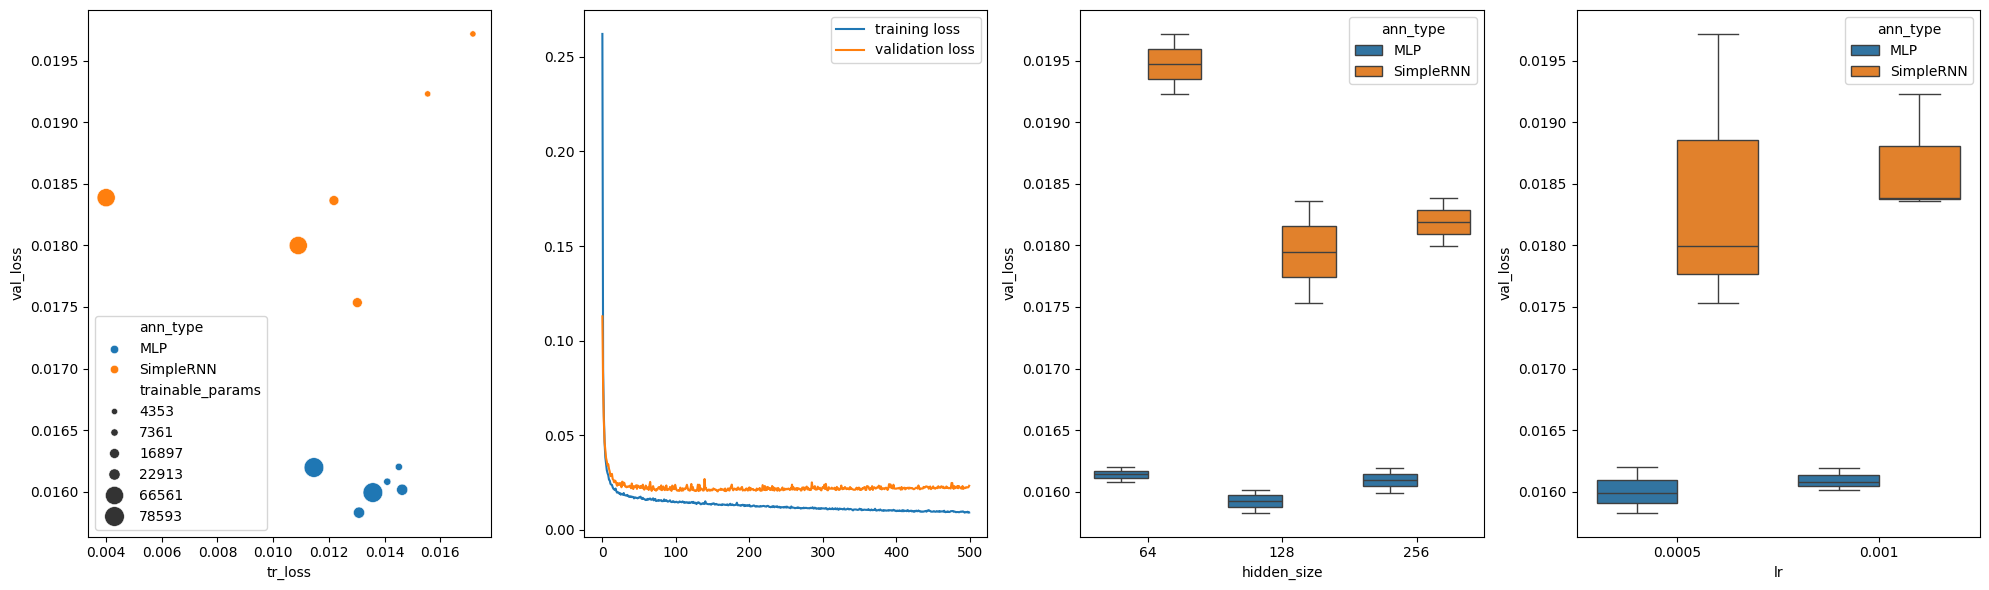

In [43]:
f, axes = plt.subplots(1,4,figsize=(20,6))
sns.scatterplot(
    data=res_df_2days, x="tr_loss", y="val_loss", size="trainable_params", hue="ann_type", sizes=(20, 200), legend="full", ax=axes[0]);

best_model_ix = res_df_2days['val_loss'].astype(float).idxmin()
print(res_df_2days.loc[best_model_ix])
axes[1].plot(histories[best_model_ix]['train_losses'], label='training loss')
axes[1].plot(histories[best_model_ix]['val_losses'], label='validation loss')
axes[1].legend()

sns.boxplot(x='hidden_size',y='val_loss', hue='ann_type', data=res_df_2days, ax = axes[2])
sns.boxplot(x='lr',y='val_loss', hue='ann_type', data=res_df_2days, ax = axes[3])

f.tight_layout()

**Comment on the results**: Interestingly, with a shorter time sequence, the MLP can now focus on less inputs to produce more accurate predictions, which is also better than what obtained on the longer sequence. 